In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from scipy.stats import linregress

sns.set_theme(style="whitegrid")

print("Performance Analytics Ready")

Performance Analytics Ready


In [2]:
processed_path = Path("../data/processed")
raw_path = Path("../data/raw")

nav = pd.read_csv(
    processed_path / "clean_nav.csv"
)

performance = pd.read_csv(
    processed_path / "clean_performance.csv"
)

benchmark = pd.read_csv(
    raw_path / "10_benchmark_indices.csv"
)

fund_master = pd.read_csv(
    processed_path / "fund_master_clean.csv"
)

nav["date"] = pd.to_datetime(
    nav["date"]
)

benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

print("Data Loaded")

Data Loaded


## Daily Return Calculation

In [3]:
nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

nav.head()

,date,amfi_code,nav,daily_return
0,2022-01-03,100016,520.4608,NaN
1,2022-01-04,100016,515.0971,-0.010306
2,2022-01-05,100016,521.7239,0.012865
3,2022-01-06,100016,515.7880,-0.011377
4,2022-01-07,100016,515.1639,-0.001210


## Annualised Return

In [4]:
annual_returns = []

for code, group in nav.groupby("amfi_code"):

    group = group.dropna()

    n = len(group)

    annual_return = (
        (1 + group["daily_return"])
        .prod()
    ) ** (252 / n) - 1

    annual_returns.append(
        [code, annual_return]
    )

annual_returns = pd.DataFrame(
    annual_returns,
    columns=[
        "amfi_code",
        "annualised_return"
    ]
)

annual_returns.head()

,amfi_code,annualised_return
0,100016,0.018121
1,100025,0.030550
2,100033,0.199217
3,101206,0.157011
4,101207,0.054121


In [5]:
annual_returns.to_csv(
    processed_path / "returns_computed.csv",
    index=False
)

print("returns_computed.csv saved")

returns_computed.csv saved


## CAGR Analysis

In [6]:
cagr_results = []

for code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date")

    start_nav = group["nav"].iloc[0]
    end_nav = group["nav"].iloc[-1]

    years = (
        (group["date"].max() -
         group["date"].min()).days
    ) / 365

    cagr = (
        (end_nav / start_nav)
        ** (1 / years)
    ) - 1

    cagr_results.append(
        [code, cagr]
    )

cagr_df = pd.DataFrame(
    cagr_results,
    columns=["amfi_code", "cagr"]
)

cagr_df.head()

,amfi_code,cagr
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


In [7]:
cagr_df.to_csv(
    processed_path / "cagr_report.csv",
    index=False
)

print("cagr_report.csv saved")

cagr_report.csv saved


## Task 3 — Sharpe Ratio

In [8]:
rf = 0.065

sharpe_results = []

for code, group in nav.groupby("amfi_code"):

    returns = (
        group["daily_return"]
        .dropna()
    )

    annual_return = (
        (1 + returns).prod()
    ) ** (252 / len(returns)) - 1

    annual_vol = (
        returns.std()
        * np.sqrt(252)
    )

    sharpe = (
        annual_return - rf
    ) / annual_vol

    sharpe_results.append(
        [code, sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.381120
1,100025,-1.042660
2,100033,0.837330
3,101206,0.746112
4,101207,-0.049875


In [12]:
sharpe_df.to_csv(
    processed_path / "sharpe_values.csv",
    index=False
)

print("sharpe_ratio")

sharpe_ratio


## Sortino Ratio Analysis

In [13]:
rf = 0.065

sortino_results = []

for code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    annual_return = (
        (1 + returns).prod()
    ) ** (252 / len(returns)) - 1

    downside_returns = returns[
        returns < 0
    ]

    downside_std = (
        downside_returns.std()
        * np.sqrt(252)
    )

    sortino = (
        annual_return - rf
    ) / downside_std

    sortino_results.append(
        [code, sortino]
    )

sortino_df = pd.DataFrame(
    sortino_results,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.561343
1,100025,-1.465040
2,100033,1.185357
3,101206,1.106475
4,101207,-0.071723


In [14]:
sortino_df.to_csv(
    processed_path / "sortino_values.csv",
    index=False
)

print("sortino_values.csv saved")

sortino_values.csv saved


## Task 5 — Alpha & Beta vs Benchmark

In [15]:
#benchmark preparation
benchmark_nifty = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

benchmark_nifty = benchmark_nifty.sort_values(
    "date"
)

benchmark_nifty["benchmark_return"] = (
    benchmark_nifty["close_value"]
    .pct_change()
)

In [16]:
#alpha beta calculation
alpha_beta_results = []

for code, group in nav.groupby("amfi_code"):

    fund = group.copy()

    merged = pd.merge(
        fund,
        benchmark_nifty[
            ["date", "benchmark_return"]
        ],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) > 30:

        slope, intercept, r, p, std = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        alpha = intercept * 252
        beta = slope

        alpha_beta_results.append(
            [code, alpha, beta]
        )

alpha_beta_df = pd.DataFrame(
    alpha_beta_results,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [17]:
alpha_beta_df.to_csv(
    processed_path / "alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved")

alpha_beta.csv saved


## Task 6 — Maximum Drawdown

In [18]:
drawdown_results = []

for code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date")

    running_max = group["nav"].cummax()

    drawdown = (
        group["nav"] /
        running_max
    ) - 1

    max_dd = drawdown.min()

    drawdown_results.append(
        [code, max_dd]
    )

max_dd_df = pd.DataFrame(
    drawdown_results,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

max_dd_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [19]:
max_dd_df.to_csv(
    processed_path / "max_drawdown.csv",
    index=False
)

print("max_drawdown.csv saved")

max_drawdown.csv saved


## Task  7 -  Fund Scorecard Model 

In [22]:
#Merge Metrics
scorecard = (
    annual_returns
    .merge(
        sharpe_df,
        on="amfi_code"
    )
    .merge(
        alpha_beta_df,
        on="amfi_code"
    )
    .merge(
        max_dd_df,
        on="amfi_code"
    )
)

scorecard = scorecard.merge(
    performance[
        [
            "amfi_code",
            "expense_ratio_pct"
        ]
    ],
    on="amfi_code"
)

scorecard.head()

,amfi_code,annualised_return,sharpe_ratio,alpha,beta,max_drawdown,expense_ratio_pct
0,100016,0.018121,-0.381120,0.037476,-0.058268,-0.247344,1.55
1,100025,0.030550,-1.042660,0.042818,0.001158,-0.043083,0.56
2,100033,0.199217,0.837330,0.271954,0.005104,-0.162172,1.38
3,101206,0.157011,0.746112,0.213998,0.021086,-0.112916,1.60
4,101207,0.054121,-0.049875,0.108971,-0.065289,-0.354469,1.53


In [23]:
#Create Ranks
scorecard["return_rank"] = (
    scorecard["annualised_return"]
    .rank(
        ascending=False
    )
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(
        ascending=False
    )
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(
        ascending=False
    )
)

scorecard["expense_rank"] = (
    scorecard["expense_ratio_pct"]
    .rank(
        ascending=True
    )
)

scorecard["drawdown_rank"] = (
    scorecard["max_drawdown"]
    .rank(
        ascending=False
    )
)

In [24]:
#Composite Score
scorecard["fund_score"] = (

    scorecard["return_rank"] * 0.30 +

    scorecard["sharpe_rank"] * 0.25 +

    scorecard["alpha_rank"] * 0.20 +

    scorecard["expense_rank"] * 0.15 +

    scorecard["drawdown_rank"] * 0.10

)

scorecard["fund_score"] = (
    100 *
    (
        scorecard["fund_score"]
        /
        scorecard["fund_score"].max()
    )
)

scorecard.head()

,amfi_code,annualised_return,sharpe_ratio,alpha,beta,max_drawdown,expense_ratio_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
0,100016,0.018121,-0.381120,0.037476,-0.058268,-0.247344,1.55,37.0,34.0,39.0,32.0,34.0,100.000000
1,100025,0.030550,-1.042660,0.042818,0.001158,-0.043083,0.56,36.0,37.0,38.0,2.0,4.0,79.634831
2,100033,0.199217,0.837330,0.271954,0.005104,-0.162172,1.38,7.0,7.0,6.0,17.0,20.0,26.966292
3,101206,0.157011,0.746112,0.213998,0.021086,-0.112916,1.60,12.0,9.0,12.0,36.5,9.0,41.081461
4,101207,0.054121,-0.049875,0.108971,-0.065289,-0.354469,1.53,27.0,27.0,27.0,28.5,38.0,79.564607


In [25]:
#Best Funds
top_funds = (
    scorecard
    .sort_values(
        "fund_score",
        ascending=False
    )
)

top_funds.head(10)

,amfi_code,annualised_return,sharpe_ratio,alpha,beta,max_drawdown,expense_ratio_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
0,100016,0.018121,-0.381120,0.037476,-0.058268,-0.247344,1.55,37.0,34.0,39.0,32.0,34.0,100.000000
7,102886,0.008070,-0.371306,0.028969,-0.042125,-0.280011,1.51,40.0,33.0,40.0,24.5,35.0,99.508427
17,119095,0.010473,-0.257283,0.048016,-0.066951,-0.516778,1.38,39.0,32.0,37.0,17.0,39.0,94.241573
22,119599,0.014130,-0.241147,0.048824,0.062002,-0.525742,0.72,38.0,31.0,36.0,5.5,40.0,87.570225
14,119092,0.043513,-0.182146,0.068995,0.009731,-0.144016,1.64,33.0,30.0,30.0,39.5,15.0,86.587079
29,120842,0.045770,-0.127091,0.078044,0.018057,-0.240035,1.56,31.0,29.0,29.0,33.0,33.0,85.955056
1,100025,0.030550,-1.042660,0.042818,0.001158,-0.043083,0.56,36.0,37.0,38.0,2.0,4.0,79.634831
4,101207,0.054121,-0.049875,0.108971,-0.065289,-0.354469,1.53,27.0,27.0,27.0,28.5,38.0,79.564607
5,101208,0.044468,-4.445598,0.060861,0.000267,-0.001622,0.79,32.0,40.0,33.0,11.0,3.0,79.073034
18,119120,0.040272,-0.736444,0.056209,-0.006414,-0.043287,0.77,34.0,35.0,34.0,9.0,5.0,77.528090


In [26]:
scorecard.to_csv(
    processed_path / "fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved")

fund_scorecard.csv saved


## Task 8 — Benchmark Comparison Chart

In [27]:
top5_codes = (
    top_funds["amfi_code"]
    .head(5)
    .tolist()
)

top5_codes

[100016, 102886, 119095, 119599, 119092]

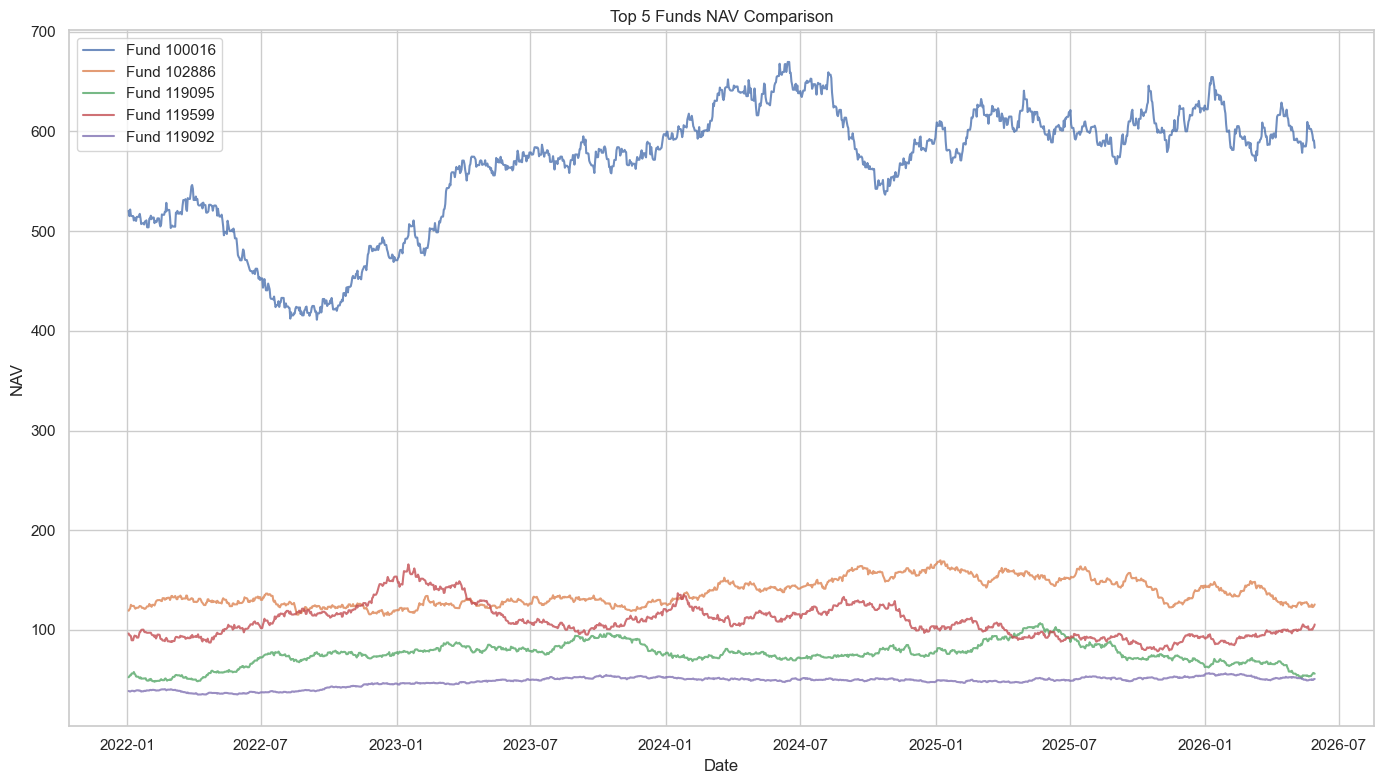

In [28]:
plt.figure(figsize=(14,8))

for code in top5_codes:

    fund = nav[
        nav["amfi_code"] == code
    ]

    plt.plot(
        fund["date"],
        fund["nav"],
        alpha=0.8,
        label=f"Fund {code}"
    )

plt.title(
    "Top 5 Funds NAV Comparison"
)

plt.xlabel("Date")
plt.ylabel("NAV")

plt.legend()

plt.tight_layout()

plt.savefig(
    "../reports/charts/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [29]:
tracking_errors = []

for code in top5_codes:

    fund = nav[
        nav["amfi_code"] == code
    ]

    merged = pd.merge(
        fund,
        benchmark_nifty[
            ["date", "benchmark_return"]
        ],
        on="date"
    )

    merged = merged.dropna()

    tracking_error = (
        merged["daily_return"]
        -
        merged["benchmark_return"]
    ).std()

    tracking_errors.append(
        [code, tracking_error]
    )

tracking_error_df = pd.DataFrame(
    tracking_errors,
    columns=[
        "amfi_code",
        "tracking_error"
    ]
)

tracking_error_df

,amfi_code,tracking_error
0,100016,0.012554
1,102886,0.014212
2,119095,0.018003
3,119599,0.017458
4,119092,0.011911
